---------------------------------
REBOUND version:     	3.19.3
REBOUND built on:    	Jun 29 2022 01:55:10
Number of particles: 	3
Selected integrator: 	ias15
Simulation time:     	0.0000000000000000e+00
Current timestep:    	0.001000
---------------------------------
<rebound.particle.Particle object at 0x1106a50c0, m=0.7 x=0.0 y=0.0 z=0.0 vx=0.0 vy=0.0 vz=0.0>
<rebound.particle.Particle object at 0x1106a55c0, m=1e-05 x=0.027781409233055013 y=0.0 z=0.0 vx=0.0 vy=31.56175213851367 vz=0.0>
<rebound.particle.Particle object at 0x1106a50c0, m=1e-05 x=-0.0035465792889616517 y=0.02747248841766554 z=0.0 vx=-31.549867203625112 vy=-4.07295613199793 vz=0.0>
---------------------------------
period 1 (day) =  2.0257237505738837 0.027820755167564368 0.027781409233055013 31.56175213851367
period 2 (day) =  2.0567831673508676 0.028104407933332513 0.02770046650350241 31.81168169430153
sim_dt =  0.002025723750573884


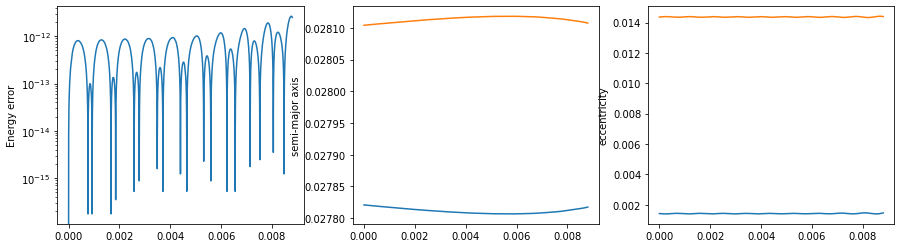

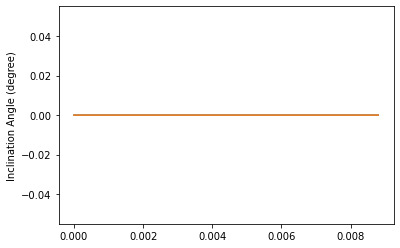

---------------------------------
REBOUND version:     	3.19.3
REBOUND built on:    	Jun 29 2022 01:55:10
Number of particles: 	3
Selected integrator: 	mercurius
Simulation time:     	5.5300569488555468e-02
Current timestep:    	0.000006
---------------------------------
<rebound.particle.Particle object at 0x122124940, m=0.7 x=-2.5318596727266643e-05 y=2.1972676873239352e-05 z=0.0 vx=-0.0002930835456304532 vy=-0.00044326090773248744 vz=0.0>
<rebound.particle.Particle object at 0x10a57dbc0, m=1e-05 x=0.027438483099950093 y=-0.004137257438139499 z=0.0 vx=4.722114464781071 vy=31.20916706067049 vz=0.0>
<rebound.particle.Particle object at 0x122124940, m=1e-05 x=0.024372494102154252 y=0.01366843844563308 z=0.0 vx=-15.756133474297428 vy=27.30789248713515 vz=0.0>
---------------------------------


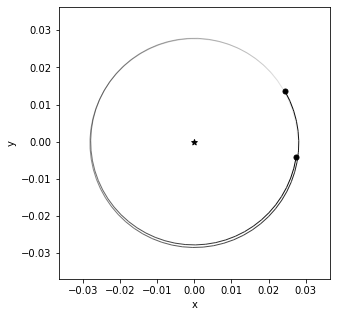

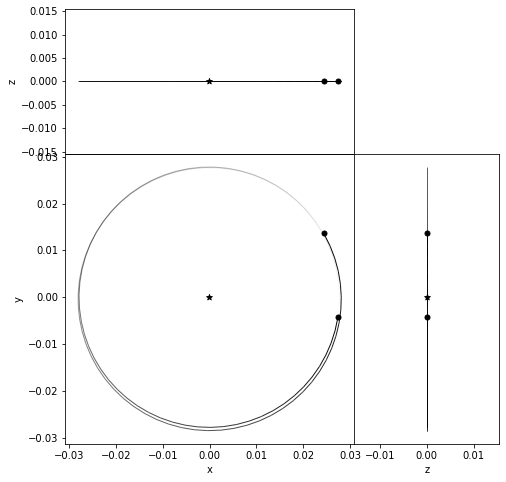

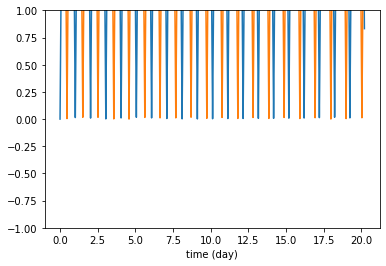

<Figure size 432x288 with 0 Axes>

In [37]:
import numpy as np
import rebound 
import random
import matplotlib.pyplot as plt

random.seed(1)

sim = rebound.Simulation()
sim.units = ('Sidereal_yr', 'AU', 'Msun')
#sim.units = ('Yr', 'AU', 'Msun')

radius = 0.005
sim.add(m=0.7, r=radius)


# sim.add(m=0.00001,x=0.027781409233055013, y=0.0, z=0.0, vx=0.0, vy=31.56175213851367, vz=0.0)
# sim.add(m=0.00001, x=0.01389070461652751*1.0, y=0.0240594061487572, z=0.0, vx=-27.333279139900668*1.01, vy=15.780876069256838*0.99, vz=0.0)

sim.add(m=0.00001,a=0.027820755167564368,e=0.0014142655104929561,omega = 0.0, inc = 0.0)
sim.add(m=0.00001,a=0.028104204340703643,e=0.01436393703840509,omega = 1.6991961363967472,inc = 0.0)

sim.status()

sim.integrator = "mercurius"
sim.ri_mercurius.hillfac = 3
#sim.dt = min([o.P for o in sim.calculate_orbits()]) * 0.0001 # 5% timestep
sim.dt = min([o.P for o in sim.calculate_orbits(primary=sim.particles[0], jacobi_masses= False)]) * 0.001 # 5% timestep
#os = sim.calculate_orbits(primary=sim.particles[0])
os = sim.calculate_orbits(primary=sim.particles[0], jacobi_masses= False)  # set helio-centric orbit
print('period 1 (day) = ', os[0].P*365.24, os[0].a, os[0].d, os[0].v)
print('period 2 (day) = ', os[1].P*365.24, os[1].a, os[1].d, os[1].v)

per = 2.02/365.24
#for o in enumerate(os):
#    print(o)
print('sim_dt = ', sim.dt*365.24)
#sim.ri_mercurius.L = "C4"

#times = np.arange(0, 1, step=0.01)*1*2*np.pi
times = np.arange(0, 10, step=0.001)*1*per   #每个周期记录数据的点的间隔由step决定，如果step=0.01,那么每隔0.01个周期记录一个点
#print(times)
#print(sim.N)
Es = np.zeros(len(times))
As = np.zeros((len(times),sim.N-1))
Eccs = np.zeros((len(times),sim.N-1))
incs = np.zeros((len(times),sim.N-1))
X0 = np.zeros((len(times)))
X1 = np.zeros((len(times)))
X2 = np.zeros((len(times)))
Y0 = np.zeros((len(times)))
Y1 = np.zeros((len(times)))
Y2 = np.zeros((len(times)))
Z0 = np.zeros((len(times)))
Z1 = np.zeros((len(times)))
Z2 = np.zeros((len(times)))
record_time = np.zeros((len(times)))

for j, time in enumerate(times):
    #print(j,time)
    sim.integrate(time)
    Es[j] = sim.calculate_energy()
    os = sim.calculate_orbits()
    record_time[j] =  time
    for i,o in enumerate(os):
        #print(i)
        As[j,i] = o.a
        Eccs[j,i] = o.e
        incs[j,i] = o.inc
        X0[j] = sim.particles[0].x
        Y0[j] = sim.particles[0].y
        Z0[j] = sim.particles[0].z
        X1[j] = sim.particles[1].x
        Y1[j] = sim.particles[1].y
        Z1[j] = sim.particles[1].z
        X2[j] = sim.particles[2].x
        Y2[j] = sim.particles[2].y
        Z2[j] = sim.particles[2].z
#perform_output(sim)

distance1 = ((Y1-Y0)**2.0+(Z1-Z0)**2.0)**0.5
k1 =  distance1/radius

distance2 = ((Y2-Y0)**2.0+(Z2-Z0)**2.0)**0.5
k2 = distance2/radius
      
fig, axs = plt.subplots(1,3,figsize=(15,4))
axs[0].set_yscale("log")
axs[0].set_ylabel("Energy error")
#axs[1].set_ylim([0.01,20])
#axs[1].set_yscale("log")
axs[1].set_ylabel("semi-major axis")
#axs[2].set_ylim([1e-6,1])
axs[0].set_yscale("log")
axs[2].set_ylabel("eccentricity")

axs[0].plot(times/(np.pi*2.),np.abs((Es-Es[0])/Es[0]))
for i in range(As.shape[1]):
    axs[1].plot(times/(np.pi*2.),As[:,i])
    axs[2].plot(times/(np.pi*2.),Eccs[:,i])
    
plt.figure()
for i in range(As.shape[1]):
    plt.plot(times/(np.pi*2.), incs[:,i]/np.pi*180.0)
plt.ylabel('Inclination Angle (degree)')
plt.show()

#fig = rebound.OrbitPlot(sim, xlim=[-1,1],ylim=[-1,1])
fig = rebound.OrbitPlot(sim)

fig = rebound.OrbitPlot(sim,slices=0.5,xlim=[-2.,2],ylim=[-2.,2])
sim.status()
plt.figure()
plt.plot(record_time*365.24, k1) # when k1 is between [0,1], and x1-x0 > 0, 
                                 # being transit. 0 corresponsing to transit center
plt.plot(record_time*365.24, k2)
#plt.plot(record_time*365.24, (X1-X0)/np.max(X1-X0))
plt.xlabel('time (day)')
plt.ylim(-1,1)
plt.show()

plt.figure()
# plt.plot(X2-X0, Y2-Y0)
# plt.plot(X1-X0, Y1-Y0)
#plt.xlabel('time (day)')
#plt.ylim(-1,1)
plt.show()

In [38]:
import numpy as np
import rebound 
import random
import matplotlib.pyplot as plt
import math

random.seed(1)

sim = rebound.Simulation()
sim.units = ('Sidereal_yr', 'AU', 'Msun')
#sim.units = ('Yr', 'AU', 'Msun')

radius = 0.005
sim.add(m=0.7, r=radius)
r = 0.1*radius

sim.add(m=0.00001,x=0.027781409233055013, y=0.0, z=0.0, vx=0.0, vy=31.56175213851367, vz=0.0)
sim.add(m=0.00001, x=0.01389070461652751*1.0, y=0.0240594061487572, z=0.0, vx=-27.333279139900668*1.01, vy=15.780876069256838*0.99, vz=0.0)
#print(sim.particles[1].inc)
#sim.status()

sim.integrator = "mercurius"
sim.ri_mercurius.hillfac = 3
#sim.dt = min([o.P for o in sim.calculate_orbits()]) * 0.0001 # 5% timestep
sim.dt = min([o.P for o in sim.calculate_orbits(primary=sim.particles[0], jacobi_masses= False)]) * 0.001 # 5% timestep
#os = sim.calculate_orbits(primary=sim.particles[0])
os = sim.calculate_orbits(primary=sim.particles[0], jacobi_masses= False)  # set helio-centric orbit
print('period 1 (day) = ', os[0].P*365.24, os[0].a, os[0].d, os[0].v)
print('period 2 (day) = ', os[1].P*365.24, os[1].a, os[1].d, os[1].v)

per = 2.02/365.24
#for o in enumerate(os):
#    print(o)
print('sim_dt = ', sim.dt*365.24)
#sim.ri_mercurius.L = "C4"

#times = np.arange(0, 1, step=0.01)*1*2*np.pi
times = np.arange(0, 100, step=0.001)*1*per   #每个周期记录数据的点的间隔由step决定，如果step=0.01,那么每隔0.01个周期记录一个点
#print(times)
#print(sim.N)
Es = np.zeros(len(times))
As = np.zeros((len(times),sim.N-1))
Eccs = np.zeros((len(times),sim.N-1))
incs = np.zeros((len(times),sim.N-1))
X0 = np.zeros((len(times)))
X1 = np.zeros((len(times)))
X2 = np.zeros((len(times)))
Y0 = np.zeros((len(times)))
Y1 = np.zeros((len(times)))
Y2 = np.zeros((len(times)))
Z0 = np.zeros((len(times)))
Z1 = np.zeros((len(times)))
Z2 = np.zeros((len(times)))
record_time = np.zeros((len(times)))

for j, time in enumerate(times):
    #print(j,time)
    sim.integrate(time)
    Es[j] = sim.calculate_energy()
    os = sim.calculate_orbits()
    record_time[j] =  time
    for i,o in enumerate(os):
        #print(i)
        As[j,i] = o.a
        Eccs[j,i] = o.e
        incs[j,i] = o.inc
        X0[j] = sim.particles[0].x
        Y0[j] = sim.particles[0].y
        Z0[j] = sim.particles[0].z
        X1[j] = sim.particles[1].x
        Y1[j] = sim.particles[1].y
        Z1[j] = sim.particles[1].z
        X2[j] = sim.particles[2].x
        Y2[j] = sim.particles[2].y
        Z2[j] = sim.particles[2].z
#perform_output(sim)

K1 = []
I1 = []
K2 = []
I2 = []
K3 = []
I3 = []
K4 = []
I4 = []
D1 = []
T1 = []
D2 = []
T2 = []

for i in range(0, len(X0)):
    if X1[i] > 0:
        distance1 = ((Y1[i]-Y0[i])**2.0+(Z1[i]-Z0[i])**2.0)**0.5
        if distance1 < radius - r:
            k1 = 1 - r**2/radius**2
            K1.append(k1)
            I1.append(i)
            
        elif distance1 < radius + r:
            #print(2)
            # angle1 = math.acos((radius**2 + distance1**2 - r**2)/(2*distance1*radius))
            # angle2 = math.acos((r**2 + distance1**2 - radius**2)/(2*distance1*r))
            # k1 = radius**2*angle1 + r**2*angle2 - np.sin(angle1)*radius*distance1
            #print(k1)
            k1 = 1 - (radius - distance1)**2/radius**2
            K1.append(k1)
            I1.append(i)
        else:
            k1 = 1
            K1.append(k1)
            I1.append(i)
    else:
        k1 = 1
        K1.append(k1)
        I1.append(i)

for i in range(0, len(X0)):
    if X2[i] > 0:
        distance2 = ((Y2[i]-Y0[i])**2.0+(Z2[i]-Z0[i])**2.0)**0.5
        if distance2 < radius - r:
            k2 = 1 - r**2/radius**2
            K2.append(k2)
            I2.append(i)
            
        elif distance2 < radius + r:
            #print(2)
            # angle1 = math.acos((radius**2 + distance1**2 - r**2)/(2*distance1*radius))
            # angle2 = math.acos((r**2 + distance1**2 - radius**2)/(2*distance1*r))
            # k1 = radius**2*angle1 + r**2*angle2 - np.sin(angle1)*radius*distance1
            #print(k1)
            k2 = 1 - (radius - distance2)**2/radius**2
            K2.append(k2)
            I2.append(i)
            if K2[i] < K2[i-1]:
                D1.append(K2[i])
                T1.append(i)
            if K2[i] > K2[i-1]:
                D2.append(K2[i-1])
                T2.append(i)
        else:
            k2 = 1
            K2.append(k2)
            I2.append(i)
    else:
        k2 = 1
        K2.append(k2)
        I2.append(i)

# for i in range(0, len(X0)):
#     if X2[i] > 0:
#         distance2 = ((Y2[i]-Y0[i])**2.0+(Z2[i]-Z0[i])**2.0)**0.5
#         k2 =  1 - (distance2/radius)**2
#         if k2 < 1:
#             K2.append(k2)
#             I2.append(i)
#         else:
#             k2 = 1.0
#             K2.append(k2)
#             I2.append(i)
#     else:
#         k2 = 1.0
#         K2.append(k2)
#         I2.append(i)

# for i in range(0, len(X0)):
#     if X1[i] > 0:
#         distance3 = ((X1[i]-X0[i])*np.tan(5/360) + Y2[i] - Y0[i])
#         k3 =  distance3/radius
#         if k3 < 1:
#             K3.append(k3)
#             I3.append(i)
#         else:
#             k3 = 1.0
#             K3.append(k3)
#             I3.append(i)
#     else:
#         k3 = 1.0
#         K3.append(k3)
#         I3.append(i)


# distance1 = ((Y1-Y0)**2.0+(Z1-Z0)**2.0)**0.5
# k1 =  distance1/radius

# distance2 = ((Y2-Y0)**2.0+(Z2-Z0)**2.0)**0.5
# k2 = distance2/radius

# distance3 = ((X1-X0)*np.tan(5/360) + Y2 - Y0)
# k3 = distance3/radius

# distance4 = ((X2-X0)*np.tan(5/360) + Y2 - Y0)
# k4 = distance4/radius

# K1 = []
# K2 = []
# K3 = []
# K4 = []


# if k1 < 1:
#     K1.append(k1)

# if k2 < 1:
#     K2.append(k2)

# if k3 < 1:
#     K3.append(k3)

# if k4 < 1:
#     K4.append(k4)

# fig, axs = plt.subplots(1,3,figsize=(15,4))
# axs[0].set_yscale("log")
# axs[0].set_ylabel("Energy error")
# #axs[1].set_ylim([0.01,20])
# #axs[1].set_yscale("log")
# axs[1].set_ylabel("semi-major axis")
# #axs[2].set_ylim([1e-6,1])
# axs[0].set_yscale("log")
# axs[2].set_ylabel("eccentricity")

#axs[0].plot(times/(np.pi*2.),np.abs((Es-Es[0])/Es[0]))
# for i in range(As.shape[1]):
#     axs[1].plot(times/(np.pi*2.),As[:,i])
#     axs[2].plot(times/(np.pi*2.),Eccs[:,i])
    
# plt.figure()
# for i in range(As.shape[1]):
#     plt.plot(times/(np.pi*2.), incs[:,i]/np.pi*180.0)
# plt.ylabel('Inclination Angle (degree)')
# plt.show()

#fig = rebound.OrbitPlot(sim, xlim=[-1,1],ylim=[-1,1])
#fig = rebound.OrbitPlot(sim)

#fig = rebound.OrbitPlot(sim,slices=0.5,xlim=[-2.,2],ylim=[-2.,2])
#sim.status()
#plt.figure()


# fig = plt.figure(figsize=(50, 5))
# plt.plot(record_time*365.24, K3)
#plt.xlim(0,20)
# plt.plot(record_time*365.24, k4)
# plt.xlabel('time (day)')
# plt.show()
# plt.figure()
# # plt.plot(X2-X0, Y2-Y0)
# # plt.plot(X1-X0, Y1-Y0)
# #plt.xlabel('time (day)')
# #plt.ylim(-1,1)
# plt.show()

period 1 (day) =  2.0257237505738837 0.027820755167564368 0.027781409233055013 31.56175213851367
period 2 (day) =  2.0568947083878775 0.028105424007534248 0.027781409233055013 31.72073855466337
sim_dt =  0.002025723750573884


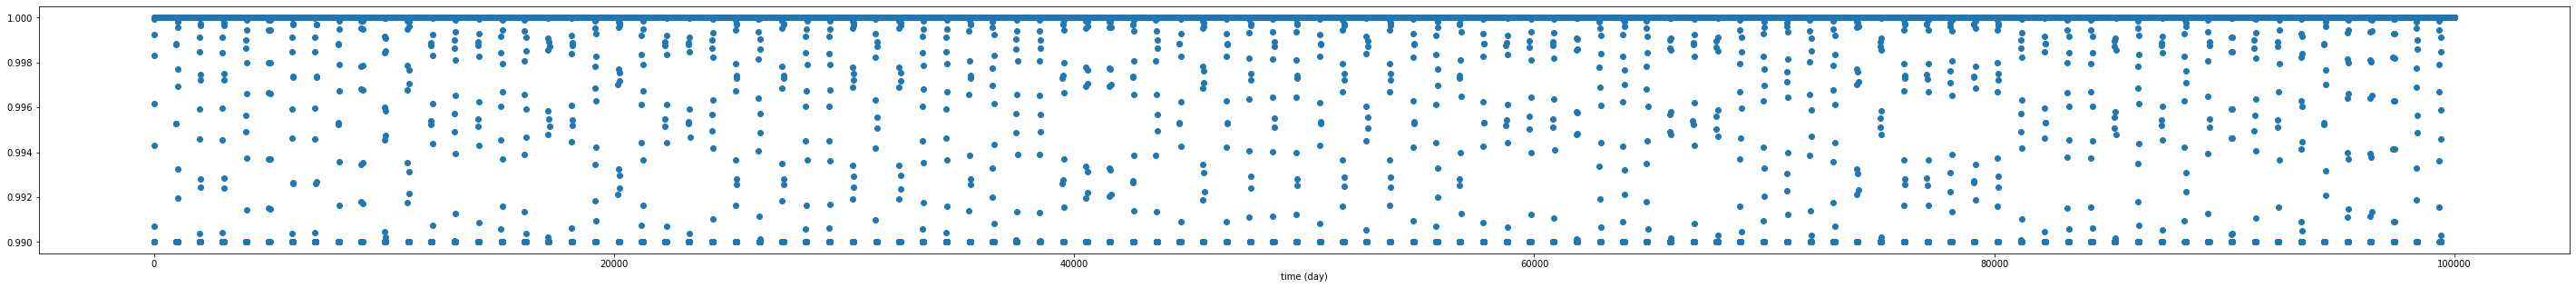

In [39]:
fig = plt.figure(figsize=(50,5))
#plt.scatter(record_time*365.24, K1) # when k1 is between [0,1], and x1-x0 > 0, 
                                 # being transit. 0 corresponsing to transit center
plt.scatter(I1, K1)
#plt.scatter(record_time*365.24, K2)
#plt.xlim(0,20)
#plt.plot(record_time*365.24, (X1-X0)/np.max(X1-X0))
plt.xlabel('time (day)')
#plt.ylim(0,1)
plt.show()

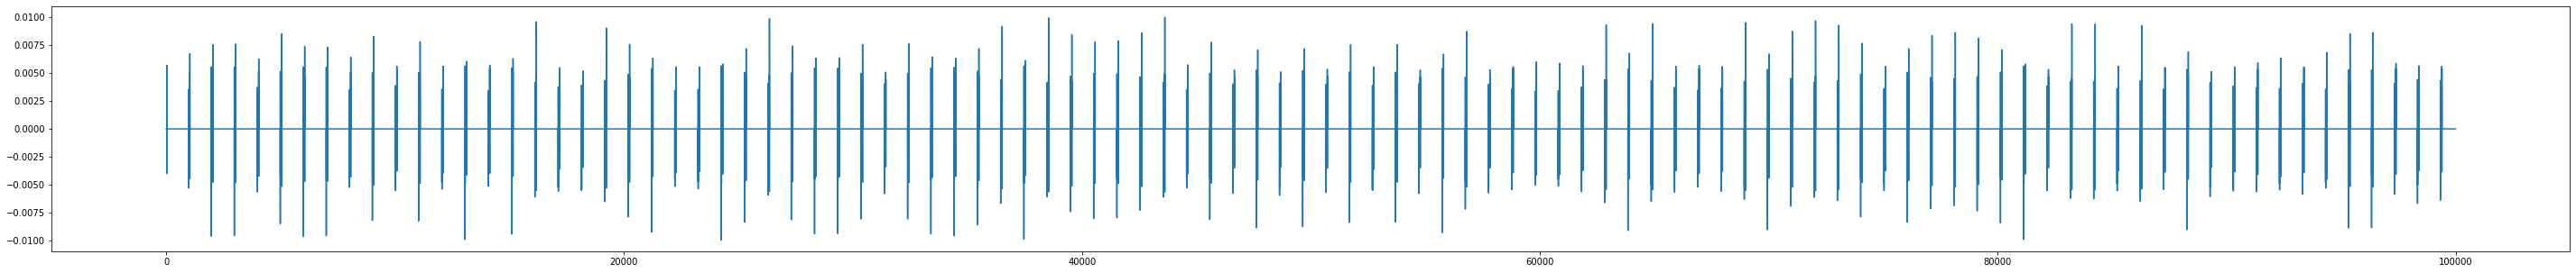

In [40]:
diff = []
fig = plt.figure(figsize=(50,5))
for i in range(0,len(K1)-1):
    d = K1[i+1] - K1[i]
    diff.append(d)
plt.plot(diff)

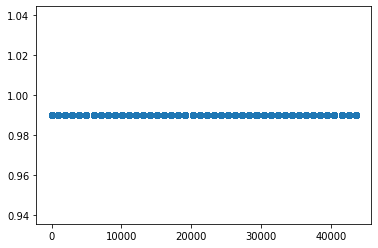

In [7]:
D = []
T = []

for i in range(0,50):
    for j in range(890*i,890*(i+1)):
        K = K1[890*i:890*(i+1)]
        I = I1[890*i:890*(i+1)]
        a = min(K)
        b = K.index(min(K)) + 890*i
        D.append(a)
        T.append(b)
plt.scatter(T,D)

In [4]:
import numpy as np

(-11.109999120150366, 11.109999958102398, -1.0999999195274184, 1.0999999744389)

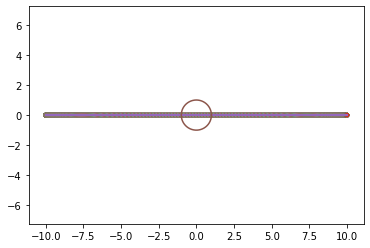

In [65]:
radius = 10.0
r = 0.1
a, b = (0., 0.)
inc = 0/180*np.pi
R = 1.0

theta = np.arange(0, 2*np.pi,0.001)
x = a + radius*np.cos(theta)
y = b + radius*np.sin(theta)*np.sin(inc)
x1 = a + R*np.cos(theta)
y1 = b + R*np.sin(theta)
fig = plt.figure()
axes = fig.add_subplot(111)
T = []
for i in range(0, len(theta)):
    x0 = x[i] + r*np.cos(theta)
    y0 = y[i] +r*np.sin(theta)
    axes.plot(x0,y0)
    k = np.sqrt((x[i]-a)**2 + (y[i]-b)**2)
    if k < R - r:
        m = 1. - r**2/R**2
        T.append(m)
    elif k < R + r:
        ang1 = np.arccos((r**2+k**2-R**2)/(2*r*k))
        ang2 = np.arccos((R**2+k**2-r**2)/(2*R*k))
        m = 1 - (ang1*r*r + ang2*R*R - r*k*np.sin(ang1))/R**2/np.pi
        T.append(m)    
    else:
        m = 1.
        T.append(m)




axes.plot(x,y)
axes.plot(x1,y1)


axes.axis('equal')

NameError: name 'theta' is not defined

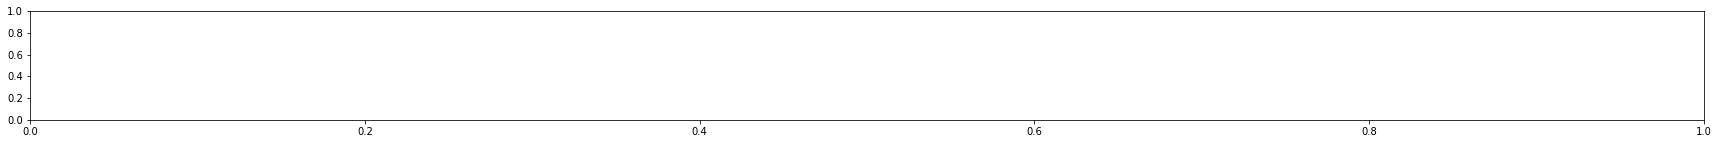

In [11]:

fig = plt.figure(figsize=(30, 2))
axes = fig.add_subplot(111)
axes.scatter(theta,T)
plt.title("Transit")
plt.xlabel("Time")
plt.ylabel("Depth")


---------------------------------
REBOUND version:     	3.19.3
REBOUND built on:    	Jun 29 2022 01:55:10
Number of particles: 	3
Selected integrator: 	ias15
Simulation time:     	0.0000000000000000e+00
Current timestep:    	0.001000
---------------------------------
<rebound.particle.Particle object at 0x12f6646c0, m=0.7 x=0.0 y=0.0 z=0.0 vx=0.0 vy=0.0 vz=0.0>
<rebound.particle.Particle object at 0x12f6647c0, m=5e-05 x=0.027781409233055013 y=0.0 z=0.0 vx=0.0 vy=31.557846732034086 vz=0.550844263702394>
<rebound.particle.Particle object at 0x12f6646c0, m=5e-05 x=-0.003544991915924786 y=0.02747248841766554 z=0.0 vx=-31.551669950166993 vy=-4.071385789633504 vz=3.93432086066991e-05>
---------------------------------
period 1 (day) =  2.0256658760595427 0.027820755167564375 0.027781409233055013 31.562653877096714
period 2 (day) =  2.0568138304360266 0.02810522256763042 0.027700263311794336 31.81326859808417
sim_dt =  0.0020256658760595425


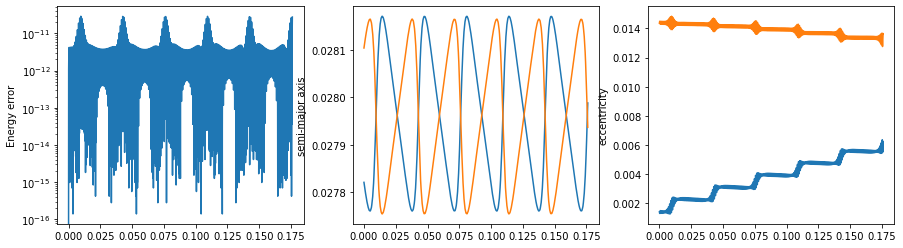

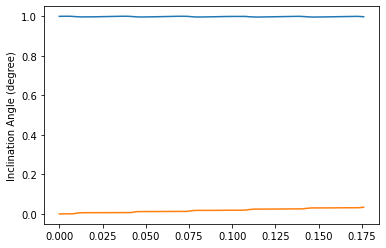

---------------------------------
REBOUND version:     	3.19.3
REBOUND built on:    	Jun 29 2022 01:55:10
Number of particles: 	3
Selected integrator: 	mercurius
Simulation time:     	1.1061164713612965e+00
Current timestep:    	0.000006
---------------------------------
<rebound.particle.Particle object at 0x12fdc2240, m=0.7 x=-0.0024942598893146588 y=0.0021716997697671736 z=4.351166528958833e-05 vx=-0.0004092562433045709 vy=-0.0019901690923078384 vz=7.765544520697268e-08>
<rebound.particle.Particle object at 0x12fdc27c0, m=5e-05 x=0.024864181402813813 y=0.007216438458961807 z=0.0001475802463602417 vx=-5.682683671950201 vy=31.091702994013634 vz=0.5379220846283416>
<rebound.particle.Particle object at 0x12fdc2240, m=5e-05 x=0.01918885546258087 y=0.019686461086313386 z=3.05371077666921e-05 vx=-20.139398871950114 vy=24.257125240703324 vz=0.011874346049757147>
---------------------------------


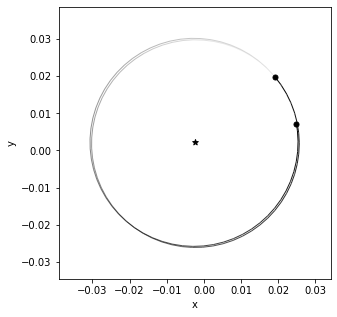

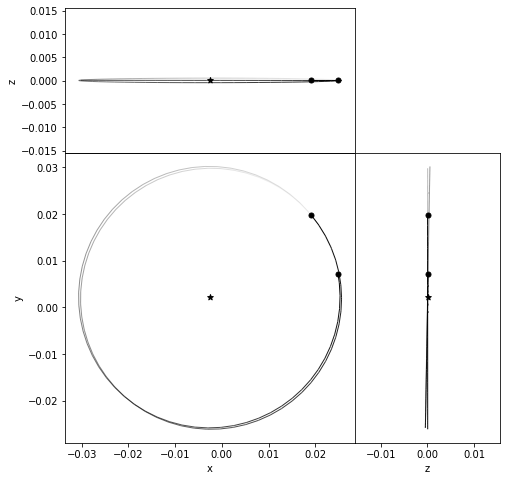

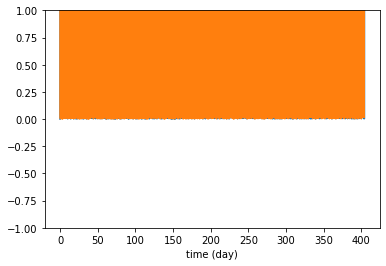

<Figure size 432x288 with 0 Axes>

In [186]:
import numpy as np
import rebound 
import random
import matplotlib.pyplot as plt

random.seed(1)

sim = rebound.Simulation()
sim.units = ('Sidereal_yr', 'AU', 'Msun')
#sim.units = ('Yr', 'AU', 'Msun')

radius = 0.005
sim.add(m=0.7, r=radius)


# sim.add(m=0.00001,x=0.027781409233055013, y=0.0, z=0.0, vx=0.0, vy=31.56175213851367, vz=0.0)
# sim.add(m=0.00001, x=0.01389070461652751*1.0, y=0.0240594061487572, z=0.0, vx=-27.333279139900668*1.01, vy=15.780876069256838*0.99, vz=0.0)

sim.add(m=0.00005,a=0.027820755167564368,e=0.0014142655104929561,omega = 0.0, inc = 1/180*np.pi)
sim.add(m=0.00005,a=0.028104204340703643,e=0.01436393703840509,omega = 1.6991961363967472,inc = 0.0)

sim.status()

sim.integrator = "mercurius"
sim.ri_mercurius.hillfac = 3
#sim.dt = min([o.P for o in sim.calculate_orbits()]) * 0.0001 # 5% timestep
sim.dt = min([o.P for o in sim.calculate_orbits(primary=sim.particles[0], jacobi_masses= False)]) * 0.001 # 5% timestep
#os = sim.calculate_orbits(primary=sim.particles[0])
os = sim.calculate_orbits(primary=sim.particles[0], jacobi_masses= False)  # set helio-centric orbit
print('period 1 (day) = ', os[0].P*365.24, os[0].a, os[0].d, os[0].v)
print('period 2 (day) = ', os[1].P*365.24, os[1].a, os[1].d, os[1].v)

per = 2.02/365.24
#for o in enumerate(os):
#    print(o)
print('sim_dt = ', sim.dt*365.24)
#sim.ri_mercurius.L = "C4"

#times = np.arange(0, 1, step=0.01)*1*2*np.pi
times = np.arange(0, 200, step=0.001)*1*per   #每个周期记录数据的点的间隔由step决定，如果step=0.01,那么每隔0.01个周期记录一个点
#print(times)
#print(sim.N)
Es = np.zeros(len(times))
As = np.zeros((len(times),sim.N-1))
Eccs = np.zeros((len(times),sim.N-1))
incs = np.zeros((len(times),sim.N-1))
X0 = np.zeros((len(times)))
X1 = np.zeros((len(times)))
X2 = np.zeros((len(times)))
Y0 = np.zeros((len(times)))
Y1 = np.zeros((len(times)))
Y2 = np.zeros((len(times)))
Z0 = np.zeros((len(times)))
Z1 = np.zeros((len(times)))
Z2 = np.zeros((len(times)))
record_time = np.zeros((len(times)))

for j, time in enumerate(times):
    #print(j,time)
    sim.integrate(time)
    Es[j] = sim.calculate_energy()
    os = sim.calculate_orbits()
    record_time[j] =  time
    for i,o in enumerate(os):
        #print(i)
        As[j,i] = o.a
        Eccs[j,i] = o.e
        incs[j,i] = o.inc
        X0[j] = sim.particles[0].x
        Y0[j] = sim.particles[0].y
        Z0[j] = sim.particles[0].z
        X1[j] = sim.particles[1].x
        Y1[j] = sim.particles[1].y
        Z1[j] = sim.particles[1].z
        X2[j] = sim.particles[2].x
        Y2[j] = sim.particles[2].y
        Z2[j] = sim.particles[2].z
#perform_output(sim)

distance1 = ((Y1-Y0)**2.0+(Z1-Z0)**2.0)**0.5
k1 =  distance1/radius

distance2 = ((Y2-Y0)**2.0+(Z2-Z0)**2.0)**0.5
k2 = distance2/radius
      
fig, axs = plt.subplots(1,3,figsize=(15,4))
axs[0].set_yscale("log")
axs[0].set_ylabel("Energy error")
#axs[1].set_ylim([0.01,20])
#axs[1].set_yscale("log")
axs[1].set_ylabel("semi-major axis")
#axs[2].set_ylim([1e-6,1])
axs[0].set_yscale("log")
axs[2].set_ylabel("eccentricity")

axs[0].plot(times/(np.pi*2.),np.abs((Es-Es[0])/Es[0]))
for i in range(As.shape[1]):
    axs[1].plot(times/(np.pi*2.),As[:,i])
    axs[2].plot(times/(np.pi*2.),Eccs[:,i])
    
plt.figure()
for i in range(As.shape[1]):
    plt.plot(times/(np.pi*2.), incs[:,i]/np.pi*180.0)
plt.ylabel('Inclination Angle (degree)')
plt.show()

#fig = rebound.OrbitPlot(sim, xlim=[-1,1],ylim=[-1,1])
fig = rebound.OrbitPlot(sim)

fig = rebound.OrbitPlot(sim,slices=0.5,xlim=[-2.,2],ylim=[-2.,2])
sim.status()
plt.figure()
plt.plot(record_time*365.24, k1) # when k1 is between [0,1], and x1-x0 > 0, 
                                 # being transit. 0 corresponsing to transit center
plt.plot(record_time*365.24, k2)
#plt.plot(record_time*365.24, (X1-X0)/np.max(X1-X0))
plt.xlabel('time (day)')
plt.ylim(-1,1)
plt.show()

plt.figure()
# plt.plot(X2-X0, Y2-Y0)
# plt.plot(X1-X0, Y1-Y0)
#plt.xlabel('time (day)')
#plt.ylim(-1,1)
plt.show()

In [187]:
r = 0.0005 #Planet radius
a, b = (0., 0.) #Stellar position
R = sim.particles[0].r #Orbit radius
inc = 9.5/180*np.pi #Inclination angle

T1 = [] #Transit

for i in range(0,len(X1)):
    radius = np.sqrt(X1[i]**2+Y1[i]**2+Z1[i]**2)
    phi = np.arctan(X1[i]/Y1[i])

    x = a + radius*np.cos(phi)
    y = b + radius*np.sin(phi)*np.sin(inc)

    if X1[i] > 0:

        k = np.sqrt((x-a)**2 + (y-b)**2)
        if k < R - r:
            m = 1. - r**2/R**2
            T1.append(m)
        elif k < R + r:
            ang1 = np.arccos((r**2+k**2-R**2)/(2*r*k))
            ang2 = np.arccos((R**2+k**2-r**2)/(2*R*k))
            m = 1 - (ang1*r*r + ang2*R*R - r*k*np.sin(ang1))/R**2/np.pi
            T1.append(m)    
        else:
            m = 1.
            T1.append(m)
    else:
        m = 1
        T1.append(m)


/var/folders/4g/jskm2hn143v97kbtf2dmm1dc0000gn/T/ipykernel_93459/2449415056.py:10: RuntimeWarning: divide by zero encountered in double_scalars
  phi = np.arctan(X1[i]/Y1[i])


In [188]:
T2 = [] #Transit

for i in range(0,len(X2)):
    radius = np.sqrt(X2[i]**2+Y2[i]**2+Z2[i]**2)
    phi = np.arctan(X2[i]/Y2[i])

    x = a + radius*np.cos(phi)
    y = b + radius*np.sin(phi)*np.sin(inc)

    if X2[i] > 0:

        k = np.sqrt((x-a)**2 + (y-b)**2)
        if k < R - r:
            m = 1. - r**2/R**2
            T2.append(m)
        elif k < R + r:
            ang1 = np.arccos((r**2+k**2-R**2)/(2*r*k))
            ang2 = np.arccos((R**2+k**2-r**2)/(2*R*k))
            m = 1 - (ang1*r*r + ang2*R*R - r*k*np.sin(ang1))/R**2/np.pi
            T2.append(m)    
        else:
            m = 1.
            T2.append(m)
    else:
        m = 1
        T2.append(m)


In [189]:
T3 = []
for i in range(0,len(times)):
    k = T1[i]+T2[i]-1
    T3.append(k)
    

Text(0, 0.5, 'Depth')

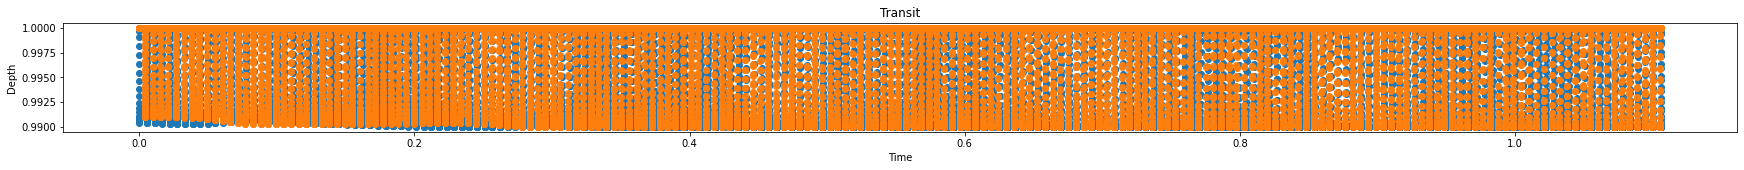

In [190]:
fig = plt.figure(figsize=(30, 2))
axes = fig.add_subplot(111)
axes.scatter(times,T1)
axes.scatter(times,T2)
plt.title("Transit")
plt.xlabel("Time")
plt.ylabel("Depth")

Text(0, 0.5, 'Depth')

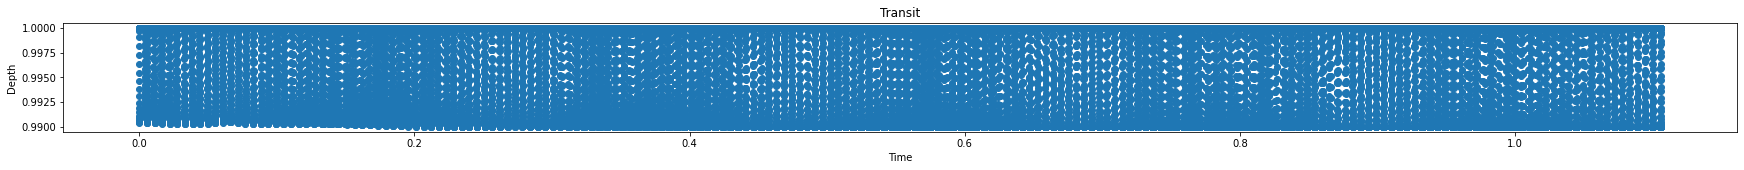

In [191]:
fig = plt.figure(figsize=(30, 2))
axes = fig.add_subplot(111)
axes.scatter(times,T3)
#axes.scatter(times,T2)
plt.title("Transit")
plt.xlabel("Time")
plt.ylabel("Depth")

Text(0, 0.5, 'Depth')

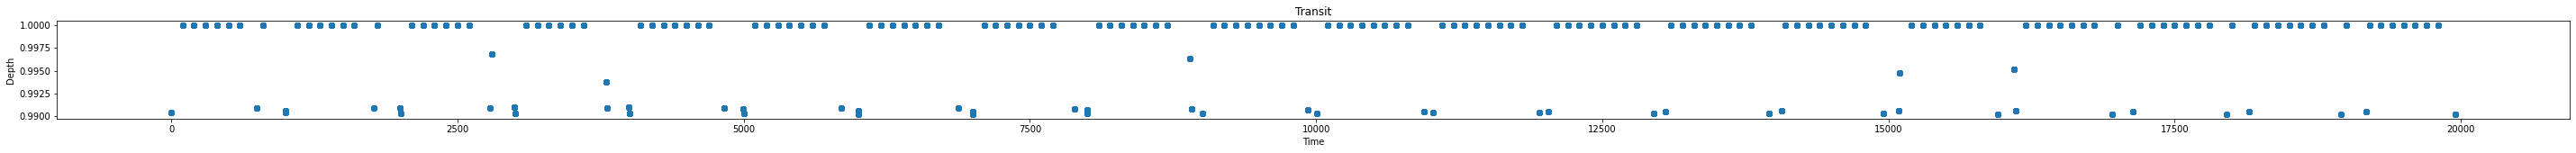

In [192]:
t = []
D = []
for i in range(0,200):
    for j in range(100*i,100*(i+1)):
        K = T3[100*i:100*(i+1)]
        I = times[100*i:100*(i+1)]
        a = min(K)
        b = K.index(min(K)) + 100*i
        D.append(a)
        t.append(b)

fig = plt.figure(figsize=(50, 2))
axes = fig.add_subplot(111)
axes.scatter(t,D)
plt.title("Transit")
plt.xlabel("Time")
plt.ylabel("Depth")
#plt.ylim(0.98996,0.99004)

Text(0, 0.5, 'Depth')

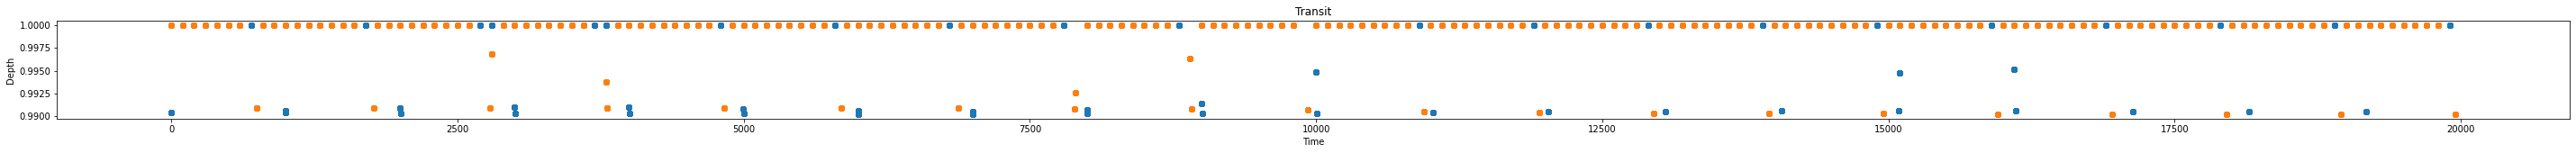

In [194]:
t1 = []
D1 = []
for i in range(0,200):
    for j in range(100*i,100*(i+1)):
        K = T1[100*i:100*(i+1)]
        I = times[100*i:100*(i+1)]
        a = min(K)
        b = K.index(min(K)) + 100*i
        D1.append(a)
        t1.append(b)

t2 = []
D2 = []
for i in range(0,200):
    for j in range(100*i,100*(i+1)):
        K = T2[100*i:100*(i+1)]
        I = times[100*i:100*(i+1)]
        a = min(K)
        b = K.index(min(K)) + 100*i
        D2.append(a)
        t2.append(b)

fig = plt.figure(figsize=(50, 2))
axes = fig.add_subplot(111)
axes.scatter(t1,D1)
axes.scatter(t2,D2)
plt.title("Transit")
plt.xlabel("Time")
plt.ylabel("Depth")
#plt.ylim(0.98996,0.99004)

In [196]:
 !where mercurial

mercurial not found
